# Problem Statement

*  Work for a consumer finance company that specialises in lending various types of loans to urban customers. When the company receives a loan application, the company has to       decide on loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:
      1. If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company
      2. If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company

* Aim is to identify patterns which indicate if a person is likely to default, which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc.

* When a person applies for a loan, there are two types of decisions that could be taken by the company:
    1. Loan accepted: If the company approves the loan, there are 3 possible scenarios described below
          * a. Fully paid: Applicant has fully paid the loan (the principal and the interest rate)
          * b. Current: Applicant is in the process of paying the instalments, i.e., the tenure of the loan is not yet completed. These candidates are not labelled as 'defaulted'.
          * c. Charged-off: Applicant has not paid the instalments in due time for a long period, i.e., he/she has defaulted on the loan
    2. Loan rejected: The company had rejected the loan (because the candidate did not meet their requirement etc.). Since the loan was rejected, there is no transactional history of those applicants with the company, and so this data is not available with the company (and thus in this dataset)  

# Business Objectives

  * company is the largest online loan marketplace, facilitating personal loans, business loans, and financing of medical procedures. Borrowers can easily access lower interest rate loans through a fast online interface.

  * Like most other lending companies, lending loans to ‘risky’ applicants is the largest source of financial loss (called credit loss). Credit loss is the amount of money lost by the lender when the borrower refuses to pay or runs away with the money owed. In other words, borrowers who default cause the largest amount of loss to the lenders. In this case, the customers labelled as 'charged-off' are the 'defaulters'.

  * If one is able to identify these risky loan applicants, then such loans can be reduced thereby cutting down the amount of credit loss.

  * company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default.  The company can utilise this knowledge for its portfolio and risk assessment.

  * To develop an understanding of the domain, advised to independently research a little about risk analytics (understanding the types of variables and their significance should be enough).

In [1]:
# NumPy is used for numerical operations
import numpy as np
# Pandas is used for data manipulation and analysis
import pandas as pd
# Matplotlib is used for creating static visualizations
import matplotlib.pyplot as plt
# Seaborn is used for making statistical graphics
import seaborn as sns

In [2]:
# Loading the loan dataset from a local path into a Pandas DataFrame  dataset that contains information about past loan applicants
loan = pd.read_csv("/content/loan.csv", sep=",", low_memory=False)

In [3]:
# Displaying a concise summary of the dataset:
# - Number of non-null values in each column
# - Data types of columns
# - Memory usage
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


## Data Understanding

In [4]:
# Display the first 5 rows of the loan DataFrame
loan.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [5]:
# Displaying all column names in the loan dataset. This helps us understand what features (variables) are present in the dataset.
# Useful for data exploration, feature selection, and understanding what information is available.
loan.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

* Some of the important columns in the dataset are loan_amount, term, interest rate, grade, sub grade, annual income, purpose of the loan etc.

*  target variable, which want to compare across the independent variables, is loan status. strategy is to figure out compare the average default rates across various independent variables and identify the  ones that affect default rate the most.

## Data Cleaning

Some columns have a large number of missing values. Let's first fix the missing values and then check for other types of data quality problems.

In [6]:
# Summarizing the number of missing (null/NaN) values in each column of the dataset. This helps in identifying which columns have incomplete data and to what extent.
# Important for deciding:
# - Whether to drop columns or rows
# - Whether to impute (fill) missing values
loan.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
tax_liens,39
tot_hi_cred_lim,39717
total_bal_ex_mort,39717
total_bc_limit,39717


In [8]:
# percentage of missing values in each column
round(loan.isnull().sum()/len(loan.index), 2)*100

,0
id,0.0
member_id,0.0
loan_amnt,0.0
funded_amnt,0.0
funded_amnt_inv,0.0
...,...
tax_liens,0.0
tot_hi_cred_lim,100.0
total_bal_ex_mort,100.0
total_bc_limit,100.0


* After see that many columns have 100% missing values, some have 65%, 33% etc. First, let's get rid of the columns having 100% missing values.

In [9]:
# Identifying columns with more than 90% missing values:
# - (loan.isnull().sum() / len(loan.index)) calculates the fraction of missing values per column.
# - Multiplying by 100 converts it to a percentage.
# - Columns where this percentage is > 90 are considered too sparse to be useful.
# - `loan.columns[...]` filters out and returns the names of such columns.
missing_columns = loan.columns[100 * (loan.isnull().sum() / len(loan.index)) > 90]

# Displaying the names of columns with more than 90% missing values. These columns will typically be dropped in the data cleaning step.
print(missing_columns)

Index(['mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
       'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
       'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
 

In [10]:
# Dropping columns with more than 90% missing values:
# - `missing_columns` contains the names of all such columns (identified previously).
# - `axis=1` specifies we are dropping columns (not rows).
# - The cleaned DataFrame is reassigned to the variable `loan`.

loan = loan.drop(missing_columns, axis=1)

# Displaying the new shape of the DataFrame after column removal:
# - Returns a tuple (number of rows, number of remaining columns).
print(loan.shape)

(39717, 55)


In [11]:
# Re-calculating the percentage of missing values in each column after dropping columns with more than 90% missing values.
# This helps in reassessing the remaining data quality.
100 * (loan.isnull().sum() / len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


In [12]:
# Identifying columns with significant missing values:
# 'desc' (~64% missing) and 'mths_since_last_delinq' (~32% missing)
# Let's examine a few sample entries from these columns to understand the nature of the data
loan.loc[:, ['desc', 'mths_since_last_delinq']].head()

,desc,mths_since_last_delinq
0,Borrower added on 12/22/11 > I need to upgra...,NaN
1,Borrower added on 12/22/11 > I plan to use t...,NaN
2,NaN,NaN
3,Borrower added on 12/21/11 > to pay for prop...,35.0
4,Borrower added on 12/21/11 > I plan on combi...,38.0


*  column description contains the comments the applicant had written while applying for the loan. Although one can use some text analysis techniques to derive new features from this column (such as sentiment, number of positive/negative words, etc.), we will not use this column in this analysis.

* Secondly, months since last delinquent represents the number of months passed since the person last fell into the 90 DPD group. There is an important reason shouldn't use this column in analysis - since at the time of loan application, we will not have this data (it gets generated months after the loan has been approved), it cannot be used as a predictor of default at the time of loan approval.

* Thus, let's drop the two columns.

In [13]:
# Dropping the columns 'desc' and 'mths_since_last_delinq' because:
# - 'desc' is a free-text field with ~64% missing values and is not useful without NLP preprocessing.
# - 'mths_since_last_delinq' has ~32% missing values and could introduce bias if imputed improperly.
loan = loan.drop(['desc', 'mths_since_last_delinq'], axis=1)

In [14]:
# Recalculating and displaying the percentage of missing values in each remaining column.
# This helps verify the data cleanliness after dropping high-missing-value columns like 'desc' and 'mths_since_last_delinq'.
100 * (loan.isnull().sum() / len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


* There are some more columns with missing values, but let's ignore them for now (since are ntot doing any modeling, don't need to impute all missing values anyway).

* But let's check whether some rows have a large number of missing values.

In [15]:
# Calculating the number of missing (NaN) values in each row of the dataset.
# This helps identify records (individual applicants) that may be incomplete and require further cleaning or removal.
loan.isnull().sum(axis=1)

,0
0,1
1,0
2,1
3,0
4,0
...,...
39712,4
39713,4
39714,5
39715,5


In [16]:
# Viewing rows with more than 5 missing values
loan[loan.isnull().sum(axis=1) > 5]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens


In [17]:
# Checking how many rows (loan applications) have more than 5 missing values.
# This helps in deciding whether to drop such rows or impute the missing values.
len(loan[loan.isnull().sum(axis=1) > 5].index)

0

* data looks clean by and large. Let's also check whether all columns are in the correct format.

In [18]:
# Displaying the updated structure of the DataFrame after cleaning:
# - Total number of entries (rows)
# - Number of non-null (non-missing) values in each column
# - Data types (object, float, int, etc.)
# - Memory usage of the DataFrame
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [19]:
# Converting the 'int_rate' column from percentage strings (like '13.56%') to float values (like 13.56)
# - First splits the string at '%' and takes the numeric part (before '%')
# - Then converts the extracted string to a float using pd.to_numeric
loan['int_rate'] = loan['int_rate'].apply(lambda x: pd.to_numeric(x.split("%")[0]))

In [20]:
# Displaying concise information about the DataFrame after cleaning:
# - Column names
# - Non-null counts for each column
# - Data types (e.g., int64, float64, object)
# - Memory usage
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [21]:
# Remove rows where 'emp_length' is missing
# Reason:  regex operation used below will throw an error on NaN values
loan = loan[~loan['emp_length'].isnull()]

In [22]:
# Import the 're' module for regular expression operations
import re

# Extract numeric values from the 'emp_length' strings using regex
# Example: '10+ years' -> 10, '2 years' -> 2, '< 1 year' -> 1
#  use re.findall('\d+', str(x)) to find all digits in the string,then select the first match [0] (assuming at least one digit is present)
loan['emp_length'] = loan['emp_length'].apply(lambda x: re.findall(r'\d+', str(x))[0])

In [23]:
# Convert the extracted string numbers to numeric type (int or float)
loan['emp_length'] = loan['emp_length'].apply(lambda x: pd.to_numeric(x))

In [24]:
# Checking the updated structure and data types of all columns in the DataFrame.
# This helps verify changes such as converting 'int_rate' and 'emp_length' to numeric types, and to ensure there are no unexpected object (string) types remaining for numeric fields.
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38642 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          38642 non-null  int64  
 1   member_id                   38642 non-null  int64  
 2   loan_amnt                   38642 non-null  int64  
 3   funded_amnt                 38642 non-null  int64  
 4   funded_amnt_inv             38642 non-null  float64
 5   term                        38642 non-null  object 
 6   int_rate                    38642 non-null  float64
 7   installment                 38642 non-null  float64
 8   grade                       38642 non-null  object 
 9   sub_grade                   38642 non-null  object 
 10  emp_title                   37202 non-null  object 
 11  emp_length                  38642 non-null  int64  
 12  home_ownership              38642 non-null  object 
 13  annual_inc                  38642 no

## Data Analysis

* Let's now move to data analysis. To start with, let's understand the objective of the analysis clearly and identify the variables that want to consider for analysis.

*  objective is to identify predictors of default so that at the time of loan application, use those variables for approval/rejection of the loan. Now, there are broadly three types of variables -

    1. those which are related to the applicant (demographic variables such as age, occupation, employment details etc.),
    2. loan characteristics (amount of loan, interest rate, purpose of loan etc.) and
    3. Customer behaviour variables (those which are generated after the loan is approved such as delinquent 2 years, revolving balance, next payment date etc.).

* Now, the customer behaviour variables are not available at the time of loan application, and thus they cannot be used as predictors for credit approval.

* Thus, going forward, will use only the other two types of variables.

In [25]:
# Defining a list of behavioral variables related to the borrower's loan history and credit behavior.
# These variables represent post-loan issuance activity and performance, and are typically not known  at the time of loan application. They are used primarily for retrospective or performance-based analysis, not predictive modeling.
# Examples include:
# - delinquencies (delinq_2yrs)
# - credit line history (earliest_cr_line)
# - revolving balance/utilization (revol_bal, revol_util)
# - payments made (total_pymnt, total_rec_prncp, etc.)
# - dates of last payment and credit pull (last_pymnt_d, last_credit_pull_d)
behaviour_var =  ["delinq_2yrs","earliest_cr_line","inq_last_6mths","open_acc","pub_rec","revol_bal","revol_util","total_acc","out_prncp",
                  "out_prncp_inv","total_pymnt","total_pymnt_inv","total_rec_prncp","total_rec_int","total_rec_late_fee","recoveries",
                  "collection_recovery_fee","last_pymnt_d","last_pymnt_amnt","last_credit_pull_d","application_type"]

In [28]:
# Removing behavioral variables from the dataset for analysis.
# These variables are outcomes or post-loan performance indicators (e.g., total payment, recoveries),
# which are not available at the time of loan application.
# Since our goal is likely to build a predictive model (e.g., default prediction),

# Drop the behavior-related columns
df = loan.drop(behaviour_var, axis=1)

In [29]:
# Display the updated dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38642 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          38642 non-null  int64  
 1   member_id                   38642 non-null  int64  
 2   loan_amnt                   38642 non-null  int64  
 3   funded_amnt                 38642 non-null  int64  
 4   funded_amnt_inv             38642 non-null  float64
 5   term                        38642 non-null  object 
 6   int_rate                    38642 non-null  float64
 7   installment                 38642 non-null  float64
 8   grade                       38642 non-null  object 
 9   sub_grade                   38642 non-null  object 
 10  emp_title                   37202 non-null  object 
 11  emp_length                  38642 non-null  int64  
 12  home_ownership              38642 non-null  object 
 13  annual_inc                  38642 no

* Typically, variables such as acc_now_delinquent, chargeoff within 12 months etc. (which are related to the applicant's past loans) are available from the credit bureau.

In [30]:
# Dropping additional non-informative or redundant columns:
# - 'title': This is derived from the 'purpose' column, so it’s redundant.
# - 'url': A unique identifier with no predictive value for modeling.
# - 'zip_code' and 'addr_state': Geographical identifiers that may not generalize well or may introduce bias.

df = df.drop(['title', 'url', 'zip_code', 'addr_state'], axis=1)

* Next, let's have a look at the target variable - loan_status. need to relabel the values to a binary form - 0 or 1, 1 indicating that the person has defaulted and 0 otherwise.

In [31]:
# Converting the 'loan_status' column to categorical type.
# This helps save memory and signals that 'loan_status' contains discrete categories (not continuous data).
df['loan_status'] = df['loan_status'].astype('category')

In [32]:
# Displaying the frequency/count of each category in the 'loan_status' column.
# This gives insight into the distribution of loan outcomes such as 'Fully Paid', 'Charged Off', etc.
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,32145
Charged Off,5399
Current,1098


You can see that fully paid comprises most of the loans. The ones marked 'current' are neither fully paid not defaulted, so let's get rid of the current loans. Also, let's tag the other two values as 0 or 1.

In [33]:
# filtering only fully paid or charged-off
df = df[df['loan_status'] != 'Current']
df['loan_status'] = df['loan_status'].apply(lambda x: 0 if x=='Fully Paid' else 1)

# converting loan_status to integer type
df['loan_status'] = df['loan_status'].apply(lambda x: pd.to_numeric(x))

# summarising the values
df['loan_status'].value_counts()

,count
loan_status,
0,32145
1,5399


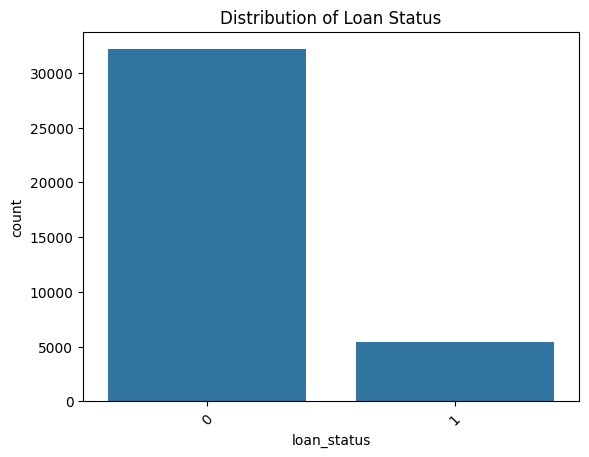

In [34]:
# Importing seaborn for advanced visualizations
import seaborn as sns

# Creating a count plot to visualize the number of occurrences of each category in the 'loan_status' column. this helps in understanding the distribution of loan statuses like 'Fully Paid', 'Charged Off', etc.
sns.countplot(x='loan_status', data=df)

# Rotating x-axis labels by 45 degrees for better readability if the category names are long
plt.xticks(rotation=45)

# Adding a title to the plot for context
plt.title("Distribution of Loan Status")

# Displaying the final plot
plt.show()

## Univariate Analysis

In [35]:
# default rate
round(np.mean(df['loan_status']), 2)

np.float64(0.14)

* The overall default rate is about 14%.  

Let's first visualise the average default rates across categorical variables.


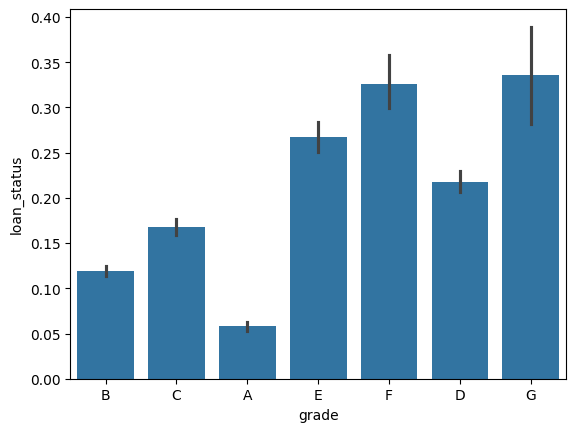

In [36]:
# Plotting default rates across loan grades:
# - The barplot shows the average loan_status (i.e., default rate) for each grade.
# - Since loan_status is binary (0 = Fully Paid, 1 = Charged Off),
#   the mean for each grade represents the proportion of defaults.
# - This helps visualize which loan grades have higher default risk.
sns.barplot(x='grade', y='loan_status', data=df)
plt.show()

In [37]:
# lets define a function to plot loan_status across categorical variables
def plot_cat(cat_var):
    sns.barplot(x=cat_var, y='loan_status', data=df)
    plt.show()

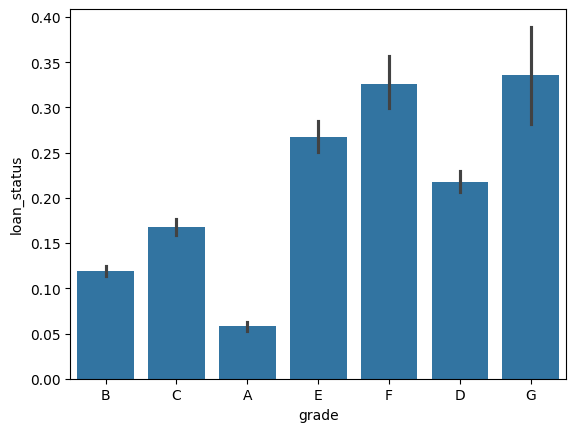

In [38]:
# Define a function to visualize default rates across categorical variables:
# - The function 'plot_cat' takes a categorical variable name as input.
# - It uses seaborn's barplot to plot the average loan_status (i.e., default rate) for each category.
# - This allows for quick comparison of default rates across different categories.
def plot_cat(cat_var):
    sns.barplot(x=cat_var, y='loan_status', data=df)
    plt.show()
# Use the function to compare default rates across loan grades
plot_cat('grade')

* Clearly, as the grade of loan goes from A to G, the default rate increases. This is expected because the grade is decided by Lending Club based on the riskiness of the loan.

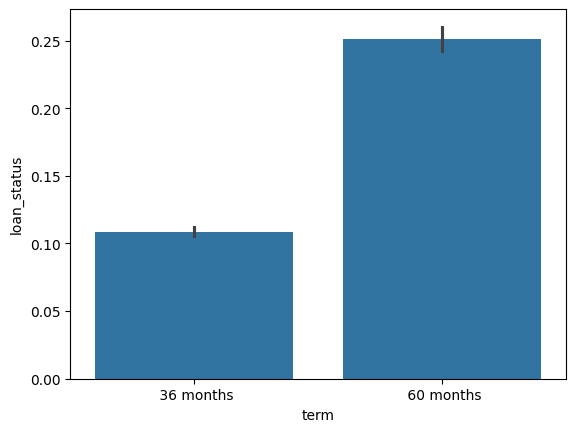

In [39]:
# Analyzing default rates across different loan terms (36 months vs 60 months) 60-month loans typically carry higher risk and thus higher default rates.
# This plot will help validate that assumption by comparing average default rate per term.
plot_cat('term')

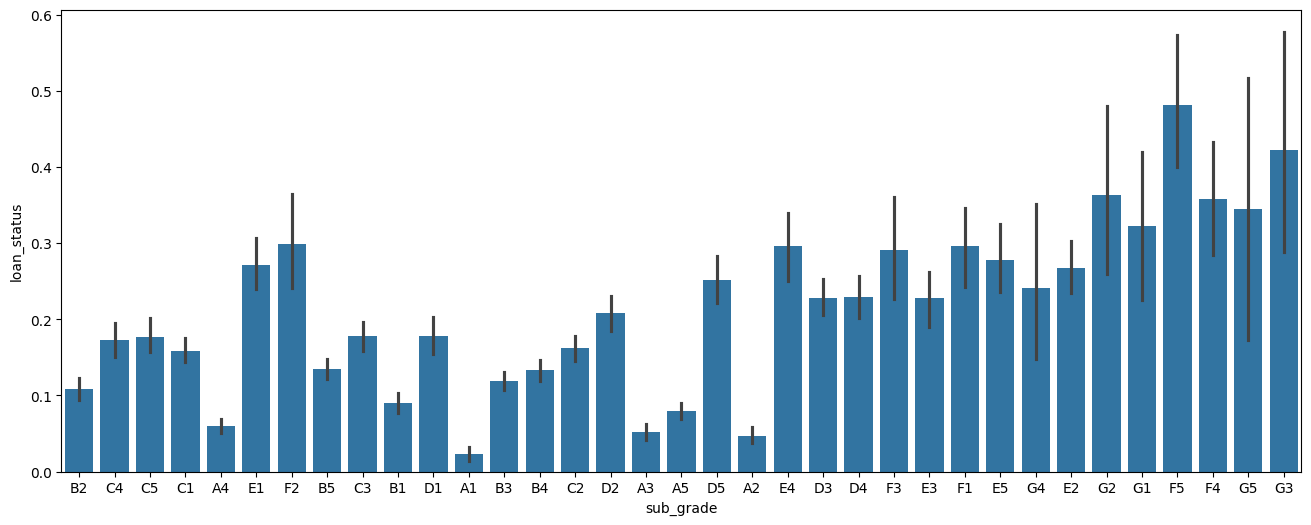

In [40]:
# sub-grade: as expected - A1 is better than A2 better than A3 and so on
plt.figure(figsize=(16, 6))
plot_cat('sub_grade')

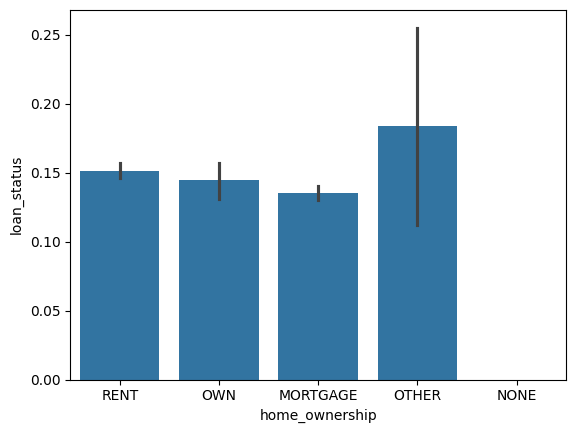

In [41]:
# Visualizing default rates across different home ownership statuses.
# goal is to check whether home ownership (OWN, MORTGAGE, RENT, etc.) affects loan default probability.
# From the plot, can assess if it's a strong predictor or not — often, it's not a great discriminator.
plot_cat('home_ownership')

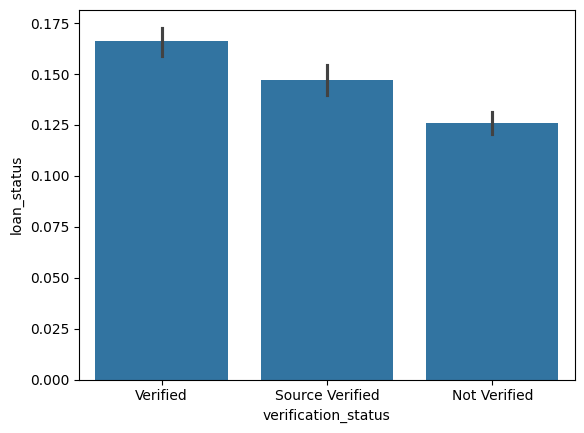

In [42]:
# Visualizing default rates across the verification status of loans.
# This helps us understand whether verifying the borrower's income (Verified, Not Verified, Source Verified) has any influence on loan default.
# Surprisingly, the plot may reveal that "Verified" loans have a higher default rate than "Not Verified" ones, which can be counterintuitive and worth further investigation.
plot_cat('verification_status')

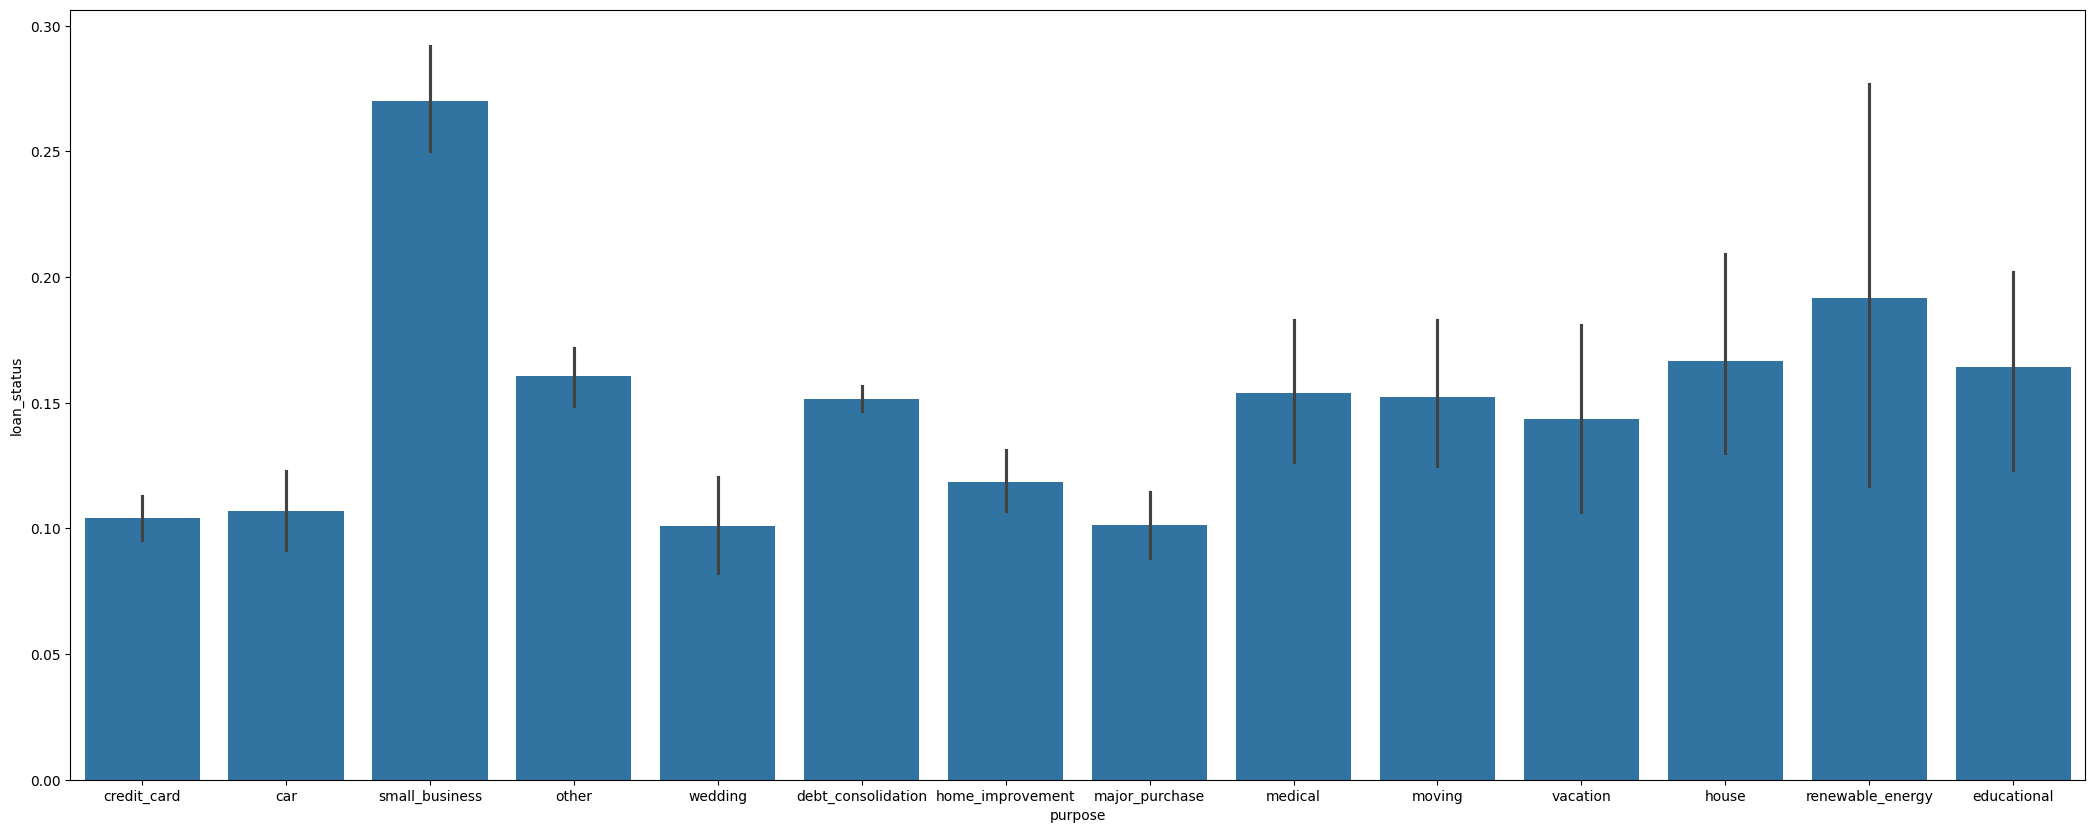

In [43]:
# Analyzing the default rates across different loan purposes.
# plotting the average default rate (loan_status) for each purpose category.
# This helps identify which loan purposes are riskier in terms of default.
# Observation: Small business loans show the highest default rate, followed by loans for renewable energy and education purposes.

# Set figure size for better readability of x-axis labels
plt.figure(figsize=(26, 10))
# Call the previously defined function to plot the bar chart
plot_cat('purpose')

In [44]:
# Let's inspect the first few entries of the 'issue_d' column.
# 'issue_d' likely contains the loan issue date (e.g., 'Jan-2014').
# later convert this column from string format to datetime and then extract year and month to analyze loan distributions over time.
df['issue_d'].head()

,issue_d
0,Dec-11
1,Dec-11
2,Dec-11
3,Dec-11
5,Dec-11


In [45]:
# Converting the 'issue_d' column from string format (e.g., 'Jan-14') to Python datetime format.
# The format '%b-%y' corresponds to an abbreviated month name and 2-digit year. This allows easier extraction of the year/month for time-based analysis later.
from datetime import datetime
df['issue_d'] = df['issue_d'].apply(lambda x: datetime.strptime(x, '%b-%y'))

In [46]:
# Extracting the numeric month and year from the 'issue_d' datetime column.
# This helps in analyzing trends over time (e.g., default rate by year or month).

# Extracts month (1–12)
df['month'] = df['issue_d'].apply(lambda x: x.month)
# Extracts full year (e.g., 2014)
df['year'] = df['issue_d'].apply(lambda x: x.year)

In [47]:
# Counting the number of loans granted each year to observe trends in loan volume over time
df.groupby('year').year.count()

,year
year,
2007,251
2008,1562
2009,4716
2010,11214
2011,19801


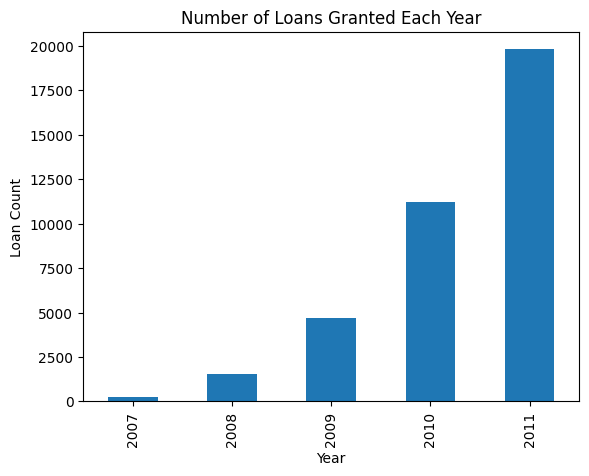

In [48]:
# Plotting the number of loans granted each year using a bar chart this helps visualize trends in loan issuance over different years
df.groupby('year').year.count().plot(kind='bar')
# Setting the title of the plot
plt.title("Number of Loans Granted Each Year")
# Labeling the Y-axis
plt.ylabel("Loan Count")
# Labeling the X-axis
plt.xlabel("Year")
# Displaying the plot
plt.show()

* see that the number of loans has increased steadily across years.

In [49]:
# Calculating the number of loans granted in each month (aggregated over all years)
# This helps identify if there are any seasonal patterns in loan issuance
df.groupby('month').month.count()

,month
month,
1,2331
2,2278
3,2632
4,2756
5,2838
6,3094
7,3253
8,3321
9,3394


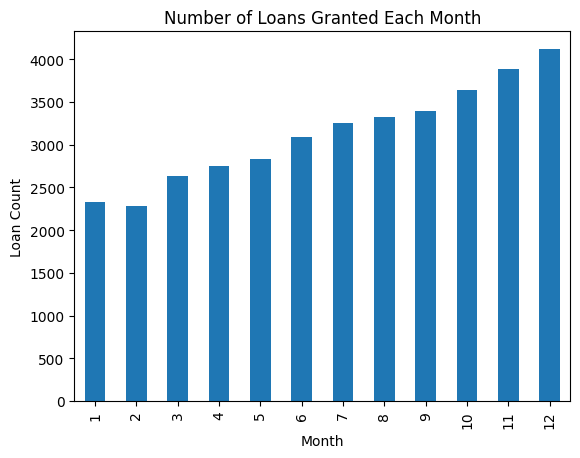

In [51]:
# Plotting the number of loans granted in each month across all years
# This helps identify seasonal trends or patterns in loan issuance throughout the calendar year
df.groupby('month').month.count().plot(kind='bar')
# Set the title of the plot
plt.title("Number of Loans Granted Each Month")
# Label for the Y-axis
plt.ylabel("Loan Count")
# Label for the X-axis
plt.xlabel("Month")
# Display the plot
plt.show()

* Most loans are granted in December, and in general in the latter half of the year.

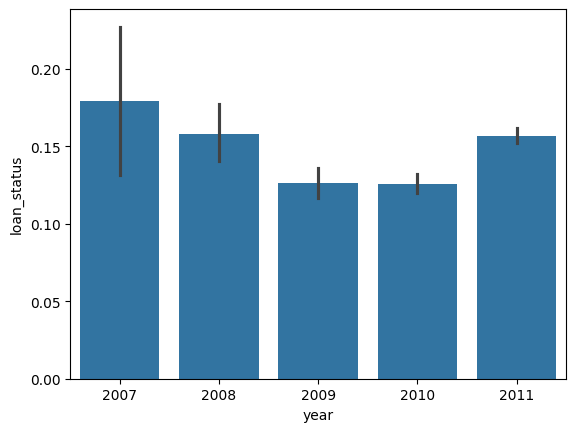

In [52]:
# Plotting the default rate (loan_status) across different years
# This visualization helps us identify how loan default rates changed over time
# Notably, default rates decreased from 2008 to 2010, but saw a sudden increase in 2011
plot_cat('year')

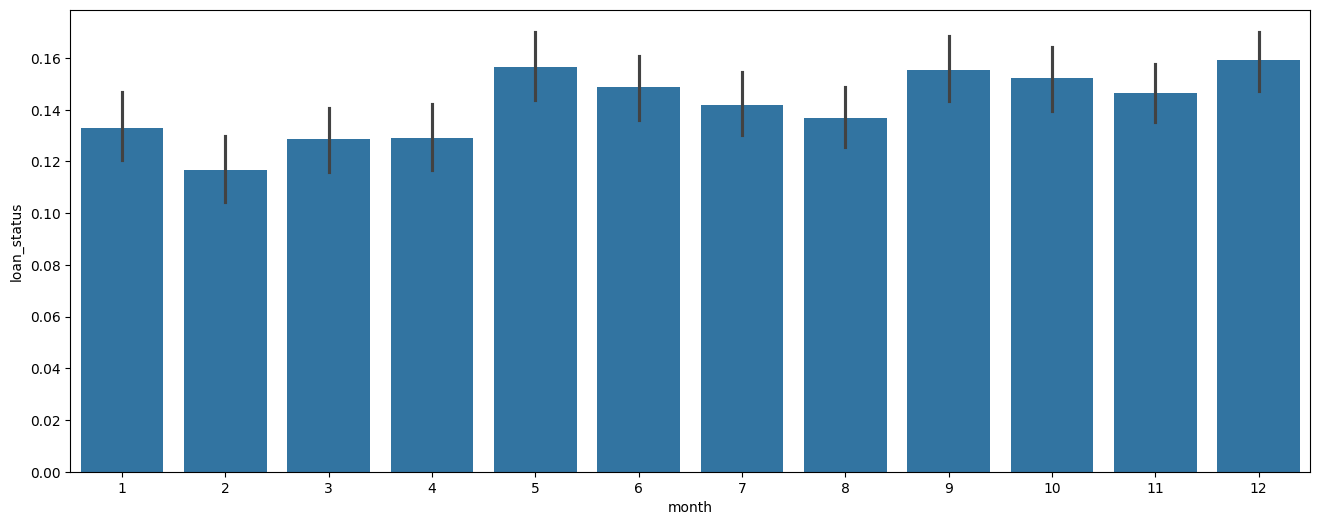

In [53]:
# Plotting default rates across different months
# This helps to check if there's any seasonal pattern in loan defaults
# Observation: There's no significant variation in default rates across months
plt.figure(figsize=(16, 6))
plot_cat('month')

* now analyse how the default rate varies across continuous variables.

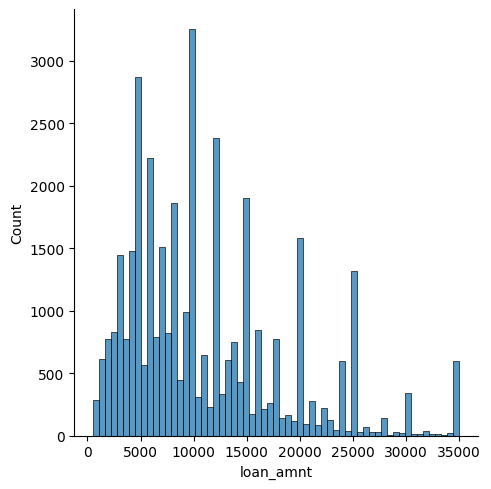

In [54]:
# Plotting the distribution of loan amounts using a histogram
# This helps visualize how loan amounts are spread across the dataset
# Observation: Most loans are concentrated around the $10,000 mark (median)
sns.displot(df['loan_amnt'])
plt.show()

* easiest way to analyse how default rates vary across continous variables is to bin the variables into discrete categories. Let's bin the loan amount variable into small, medium, high, very high.

In [56]:
# Binning the loan amount into categorical ranges:
# - 'low' for loans less than $5,000
# - 'medium' for loans between $5,000 and $14,999
# - 'high' for loans between $15,000 and $24,999
# - 'very high' for loans of $25,000 and above
# This transformation helps in analyzing loan default rates across different loan size categories.
def loan_amount(x):
    if x < 5000:
        return 'low'
    elif x < 15000:
        return 'medium'
    elif x < 25000:
        return 'high'
    else:
        return 'very high'
df['loan_amnt'] = df['loan_amnt'].apply(lambda x: loan_amount(x))

In [57]:
# Displaying the frequency (count) of each category in the 'loan_amnt' column
# This helps understand how many loans fall into each loan amount bin
# (i.e., 'low', 'medium', 'high', 'very high') after the binning transformation.
df['loan_amnt'].value_counts()

,count
loan_amnt,
medium,20157
high,7572
low,7095
very high,2720


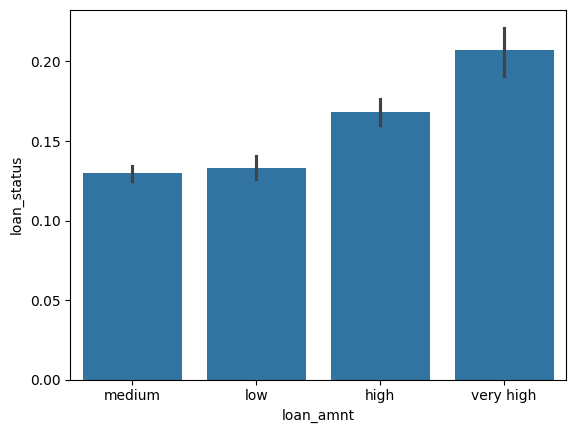

In [58]:
# Plotting default rates across different loan amount categories ('low', 'medium', 'high', 'very high')
# This helps visualize the trend that larger loan amounts tend to have higher default rates
plot_cat('loan_amnt')

In [59]:
# Converting the 'funded_amnt_inv' column into categorical bins using the same loan_amount function
# This categorizes the funded amount invested into 'low', 'medium', 'high', and 'very high' ranges
df['funded_amnt_inv'] = df['funded_amnt_inv'].apply(lambda x: loan_amount(x))

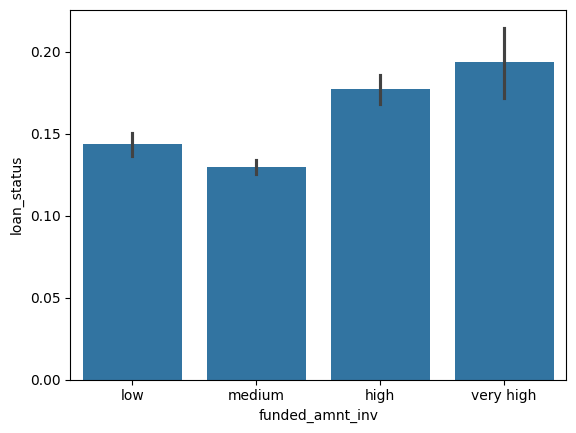

In [60]:
# Plotting the default rates across different funded amount investment categories
# This helps in analyzing how the default rate varies with the amount of money invested
plot_cat('funded_amnt_inv')

In [61]:
# Binning the interest rate into three categories: 'low', 'medium', and 'high'
# This transformation helps categorize the interest rates into broader ranges for easier analysis
def int_rate(n):
    if n <= 10:
        return 'low'
    elif n > 10 and n <= 15:
        return 'medium'
    else:
        return 'high'

# Applying the binning function to the 'int_rate' column to categorize interest rates
df['int_rate'] = df['int_rate'].apply(lambda x: int_rate(x))

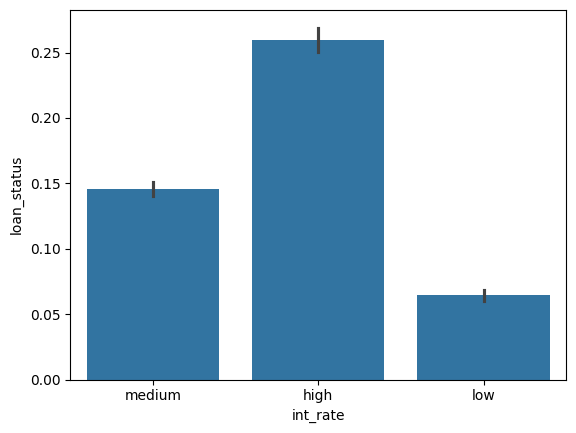

In [62]:
# Comparing default rates across the different interest rate categories ('low', 'medium', 'high')
# Higher interest rates tend to have higher default rates, as expected, likely due to the increased financial burden on the borrower
plot_cat('int_rate')

In [64]:
# Binning the 'debt to income ratio' (dti) into categorical values ('low', 'medium', 'high')
# The categorization helps in understanding the relationship between debt-to-income ratio and loan default risk.
# Low debt-to-income ratios suggest more manageable debt, while high ratios suggest higher risk of default.
def dti(n):
    if n <= 10:
        return 'low'
    elif n > 10 and n <= 20:
        return 'medium'
    else:
        return 'high'
df['dti'] = df['dti'].apply(lambda x: dti(x))

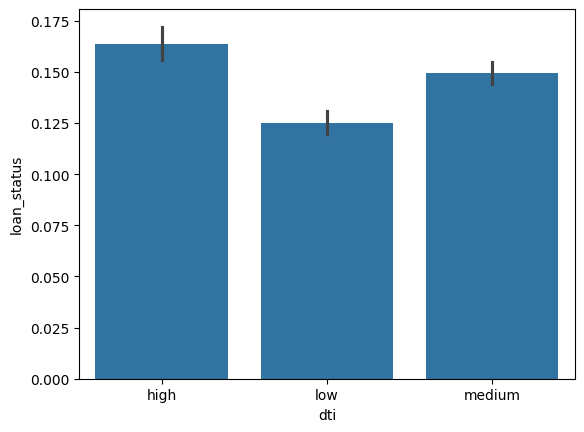

In [65]:
# Comparing default rates across the debt-to-income ratio categories ('low', 'medium', 'high') to identify the impact of dti on loan defaults.
# As expected, a higher debt-to-income ratio correlates with a higher default rate, indicating that borrowers with higher dti are more likely to default.
plot_cat('dti')

In [67]:
# Creating categories for the funded amount: 'low', 'medium', and 'high' based on the loan amount.
# The 'funded_amnt' column is transformed into categorical values to simplify the analysis of the relationship between loan amounts and defaults.
df['funded_amnt'] = df['funded_amnt'].apply(lambda x: loan_amount(x))

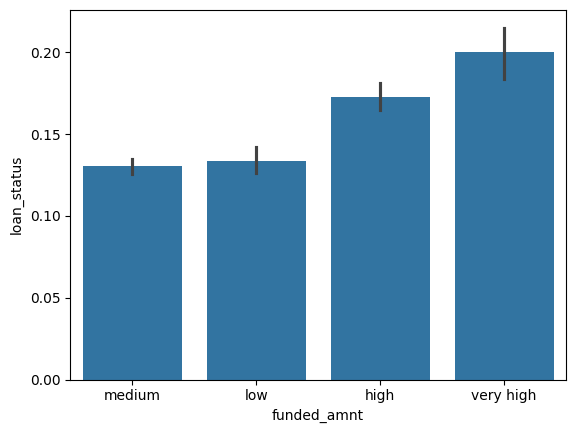

In [68]:
# Plotting the default rates across different funded amounts (low, medium, high).
# The plot will show the default rates (loan status) for each category of 'funded_amnt'.
plot_cat('funded_amnt')

In [70]:
# The function 'installment' categorizes the loan installment amount into 4 categories based on predefined thresholds:
# - 'low' for installment amounts <= 200
# - 'medium' for installment amounts between 200 and 400
# - 'high' for installment amounts between 400 and 600
# - 'very high' for installment amounts > 600
def installment(n):
    if n <= 200:
        return 'low'
    elif n > 200 and n <= 400:
        return 'medium'
    elif n > 400 and n <= 600:
        return 'high'
    else:
        return 'very high'
df['installment'] = df['installment'].apply(lambda x: installment(x))

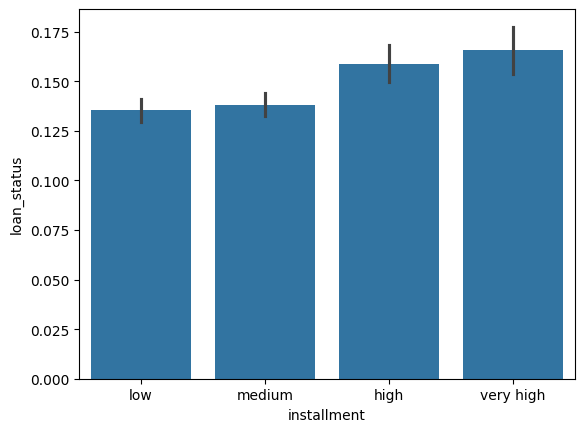

In [71]:
# The function 'plot_cat' is used to compare the default rates across categorical variables.
# In this case, we are comparing how the installment amount categories (low, medium, high, very high) correlate with loan defaults.
plot_cat('installment')

In [73]:
# The 'annual_income' function categorizes the 'annual_inc' values into four categories:
# - 'low' for annual income <= 50,000
# - 'medium' for annual income between 50,001 and 100,000
# - 'high' for annual income between 100,001 and 150,000
# - 'very high' for annual income > 150,000
def annual_income(n):
    if n <= 50000:
        return 'low'
    elif n > 50000 and n <= 100000:
        return 'medium'
    elif n > 100000 and n <= 150000:
        return 'high'
    else:
        return 'very high'
df['annual_inc'] = df['annual_inc'].apply(lambda x: annual_income(x))

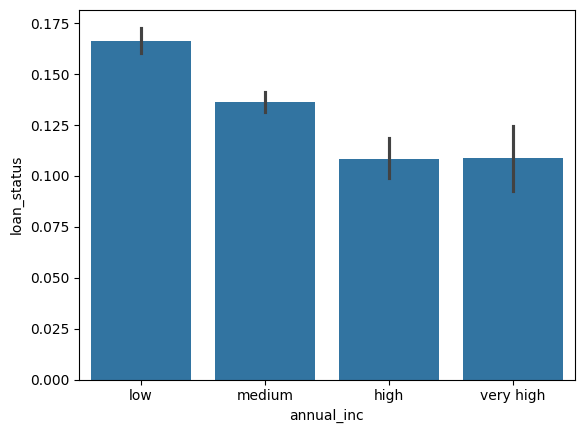

In [74]:
# Using the previously defined 'plot_cat' function to plot default rates across the 'annual_inc' categories
# The expected observation: lower annual income tends to correlate with higher default rates
plot_cat('annual_inc')

In [75]:
# line filters the dataset df to remove rows where the emp_length (employment length) column has missing values (i.e., NaN values).
df = df[~df['emp_length'].isnull()]

In [77]:
# The 'emp_length' function categorizes the employment length into four categories:
# - 'fresher' for employment length <= 1 year
# - 'junior' for employment length between 2 and 4 years
# - 'senior' for employment length between 5 and 9 years
# - 'expert' for employment length >= 10 years
def emp_length(n):
    if n <= 1:
        return 'fresher'
    elif n > 1 and n <= 4:
        return 'junior'
    elif n > 4 and n <= 9:
        return 'senior'
    else:
        return 'expert'

"""
Apply a function (emp_length) to the emp_length column of the DataFrame df, transforming the numerical values of emp_length into categorical
labels based on predefined bins (e.g., 'fresher', 'junior', 'senior', 'expert').
"""
df['emp_length'] = df['emp_length'].apply(lambda x: emp_length(x))

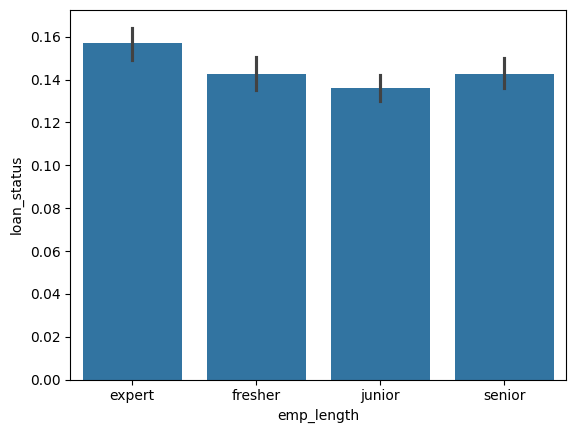

In [78]:
"""
Visualize the default rate (loan_status) across different categories of the emp_length variable, which represents the years of employment of the loan
applicants. The function plot_cat (defined earlier) is designed to create a bar plot of the default rates across any categorical variable, in this case,
the emp_length variable.
"""
plot_cat('emp_length')

## Segmented Univariate Analysis

 Now, comparing the default rates across various variables, some of the important predictors are the purpose of the loan, interest rate, annual income, grade, etc.

In the credit industry, one of the most important factors affecting default is the purpose of the loan - home loans perform differently than credit cards, credit cards are very different from debt consolidation loans, etc.

This comes from business understanding, though let's again have a look at the default rates across the purpose of the loan.


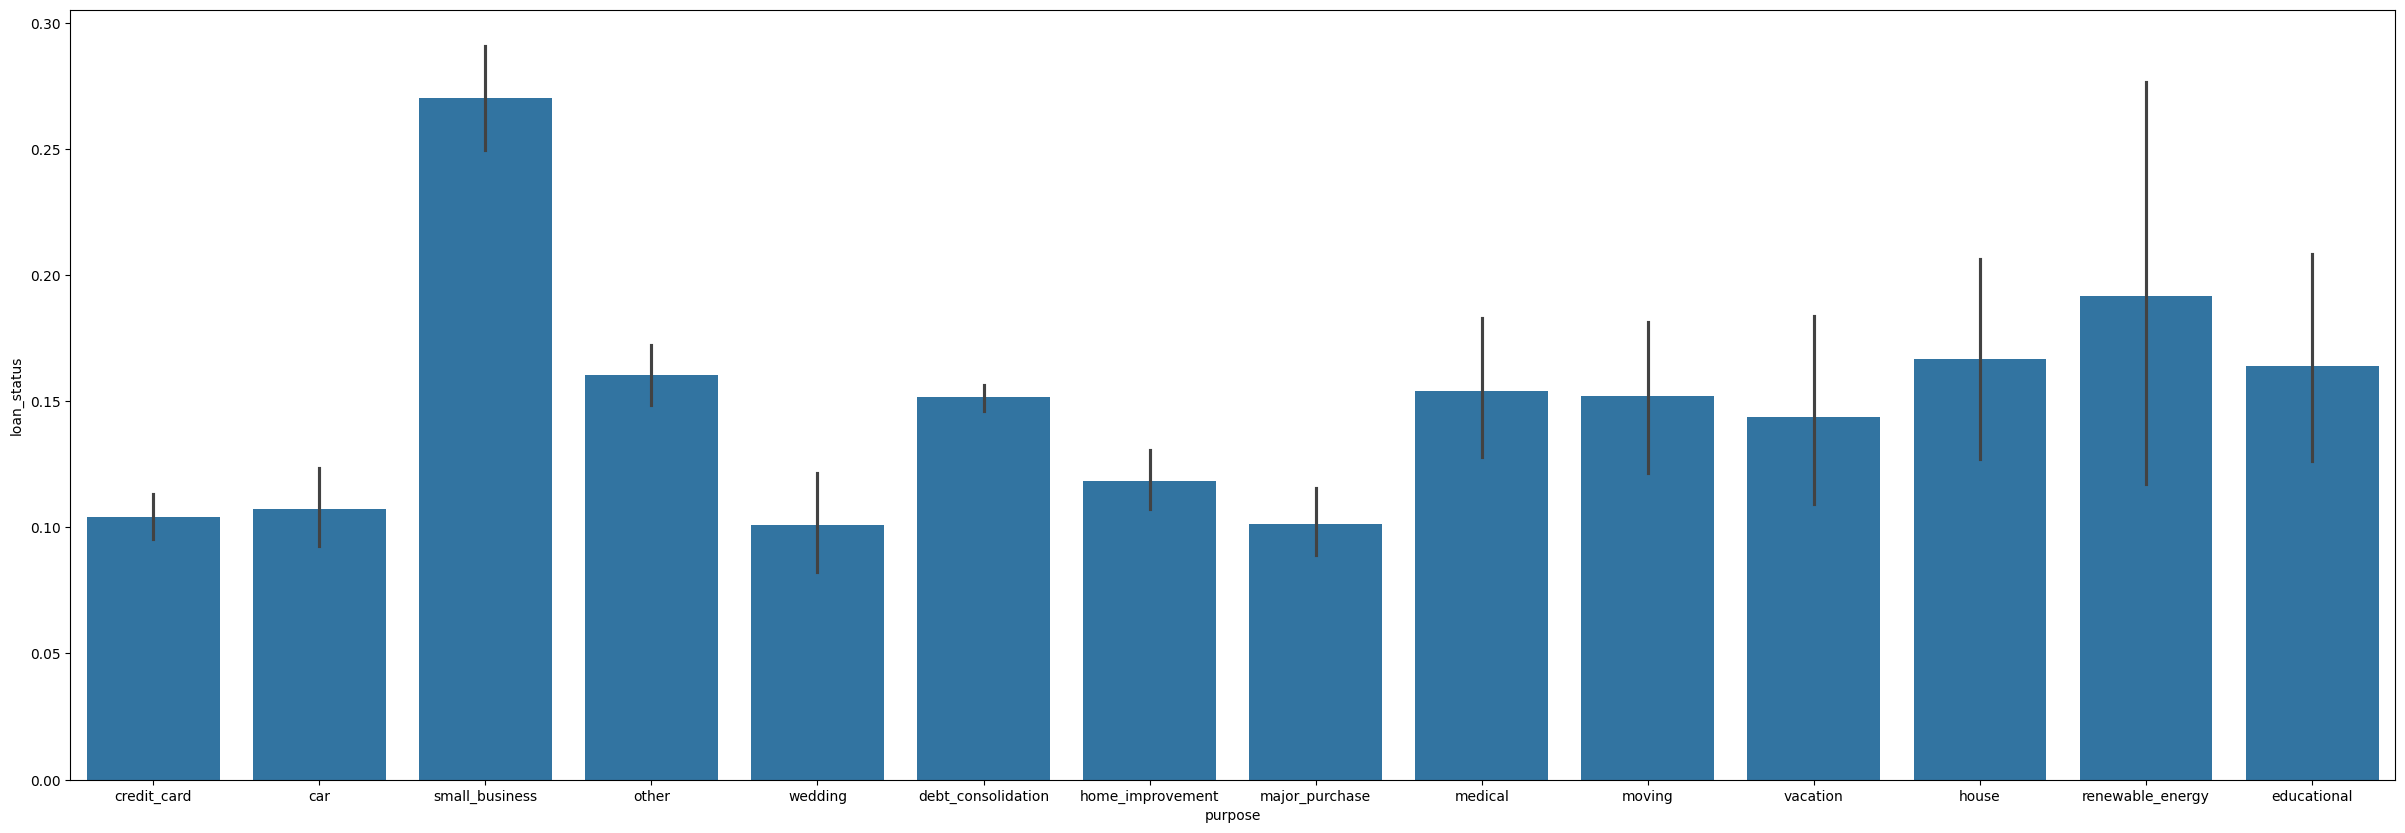

In [84]:
# purpose: small business loans defualt the most, then renewable energy and education
plt.figure(figsize=(30, 10))
plot_cat('purpose')

* In the upcoming analyses, we will segment the loan applications across the purpose of the loan, since that is a variable affecting many other variables - the type of applicant, interest rate, income, and finally the default rate.

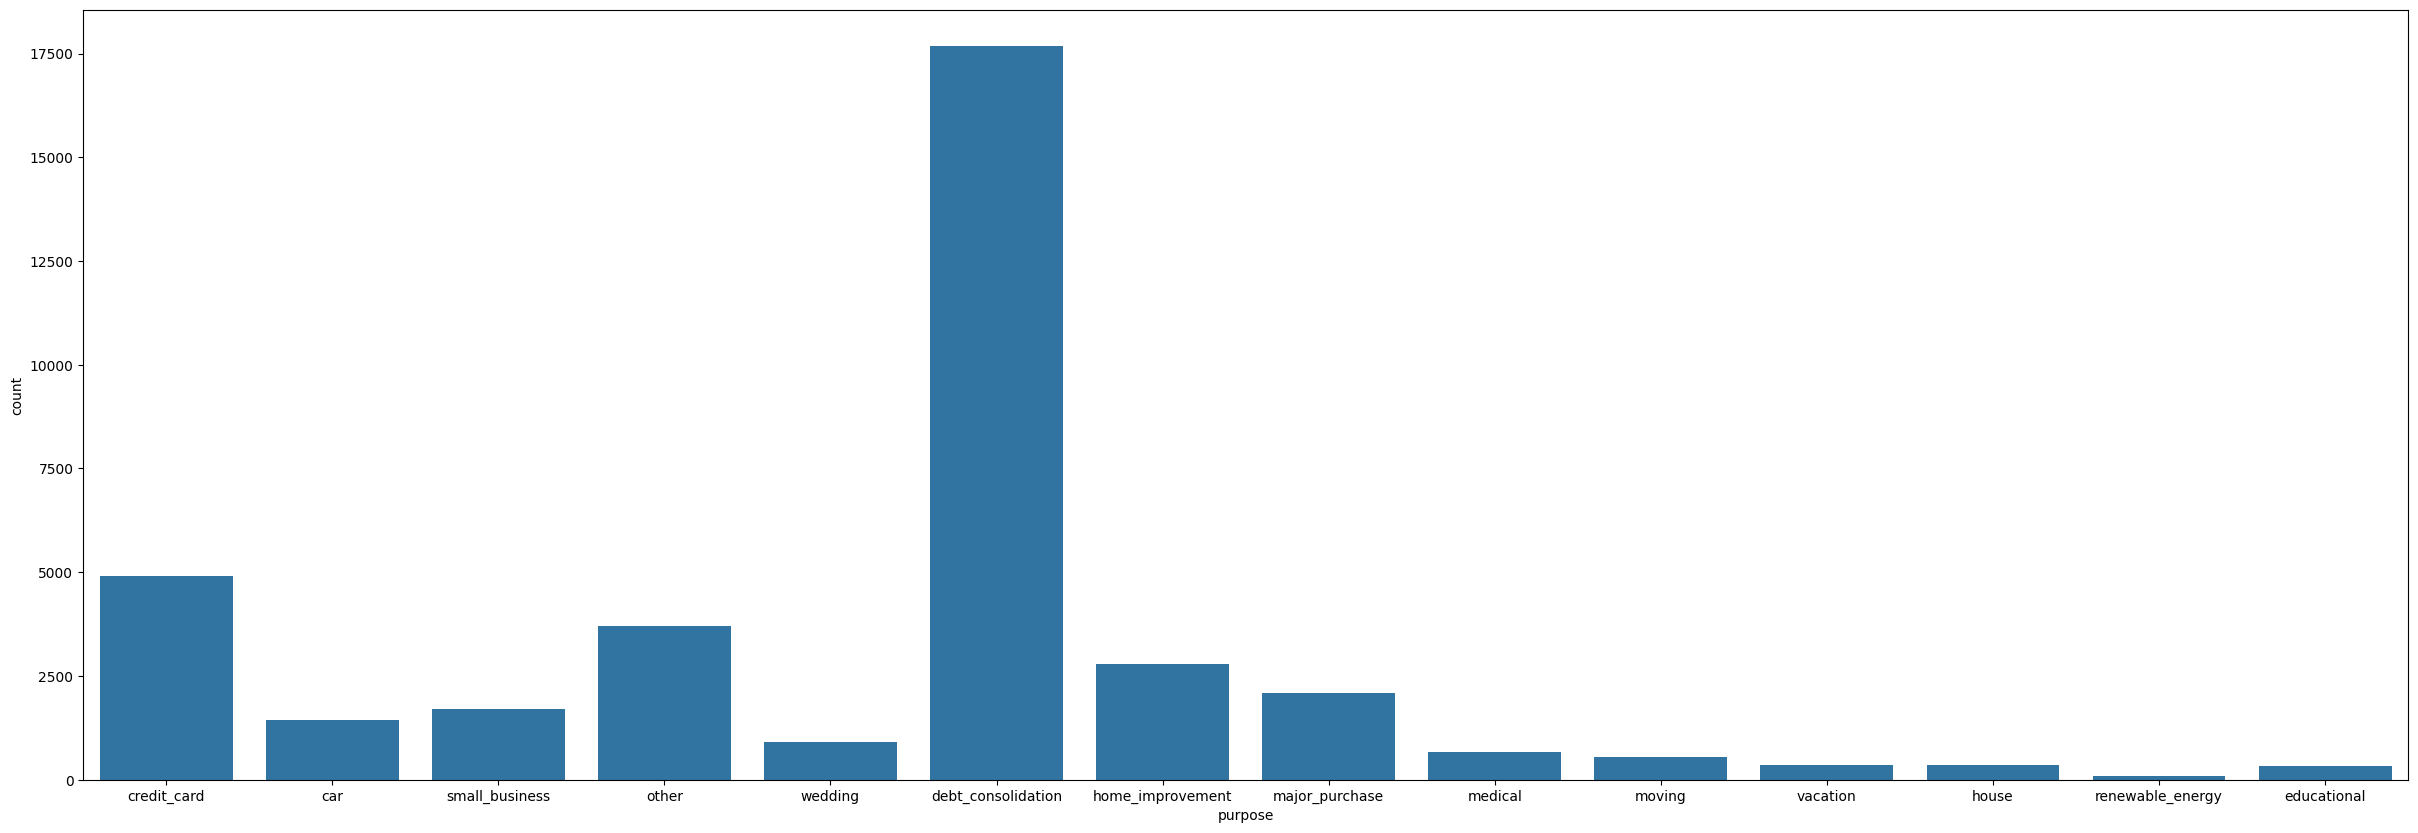

In [87]:
# Set the figure size to 25 inches wide by 16 inches tall
plt.figure(figsize=(30, 10))
# Create a count plot of loan purpose to show the number of loans for each type
sns.countplot(x='purpose', data=df)
# Display the plot
plt.show()

*  analyse the top 4 types of loans based on purpose: consolidation, credit card, home improvement and major purchase.

In [88]:
# Define a list of loan purposes to focus on
main_purposes = ["credit_card", "debt_consolidation", "home_improvement", "major_purchase"]
# Filter the DataFrame to include only rows where the 'purpose' is one of the main_purposes
df = df[df['purpose'].isin(main_purposes)]
# Display the count of each loan purpose in the filtered DataFrame
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,17675
credit_card,4899
home_improvement,2785
major_purchase,2080


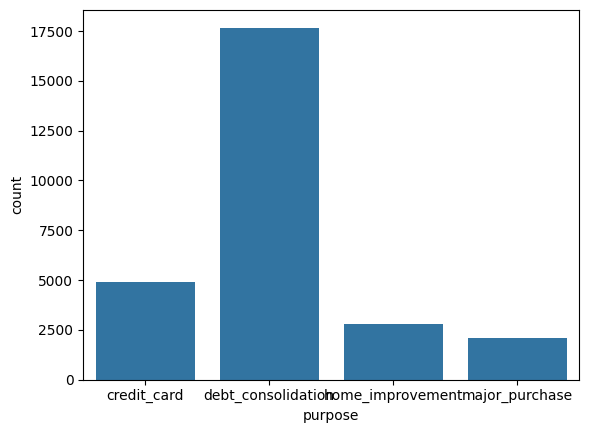

In [98]:
# Plotting the number of loans for each purpose
sns.countplot(x=df['purpose'])

# Adjust the size of the plot to make it more readable
sns.countplot(figsize=(150, 150))

# Display the plot
plt.show()

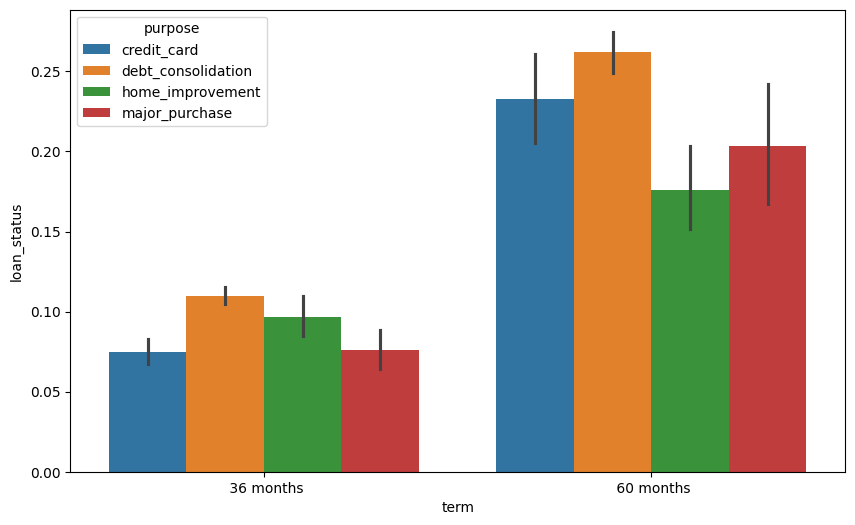

In [99]:
# Set the figure size for the plot to ensure it's clear and legible
plt.figure(figsize=[10, 6])

# Create a bar plot to compare default rates across loan terms, with loan purpose as a hue
sns.barplot(x='term', y="loan_status", hue='purpose', data=df)

# Display the plot
plt.show()

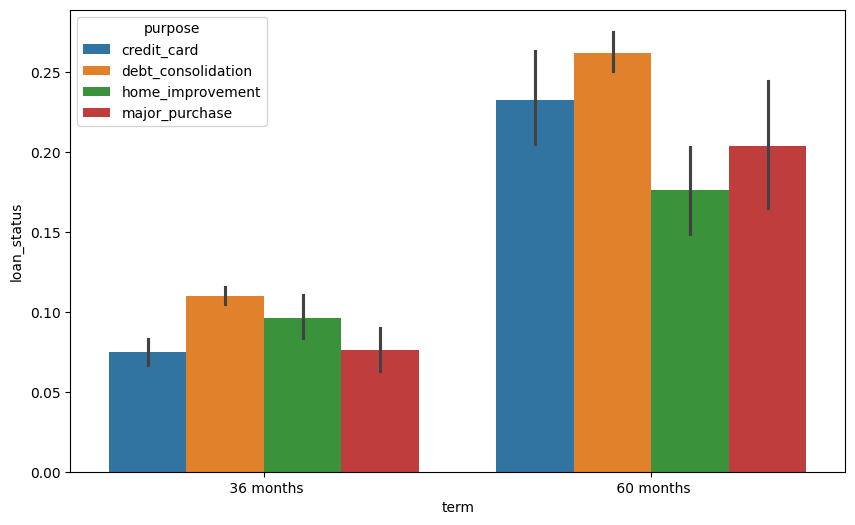

In [100]:
# Define a function that takes a categorical variable as input and plots the default rate segmented by loan purpose
def plot_segmented(cat_var):
    # Set the figure size for the plot
    plt.figure(figsize=(10, 6))
    # Create a bar plot to compare default rates for the given categorical variable, with loan purpose as a hue
    sns.barplot(x=cat_var, y='loan_status', hue='purpose', data=df)
    # Display the plot
    plt.show()
# Call the function to plot the default rate segmented by loan term (as the categorical variable)
plot_segmented('term')

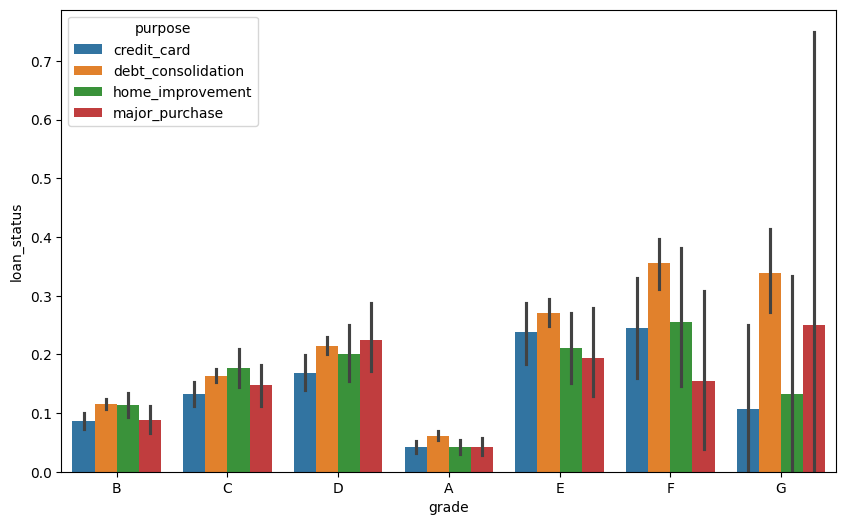

In [101]:
# Call the function to plot the default rate segmented by loan grade
plot_segmented('grade')

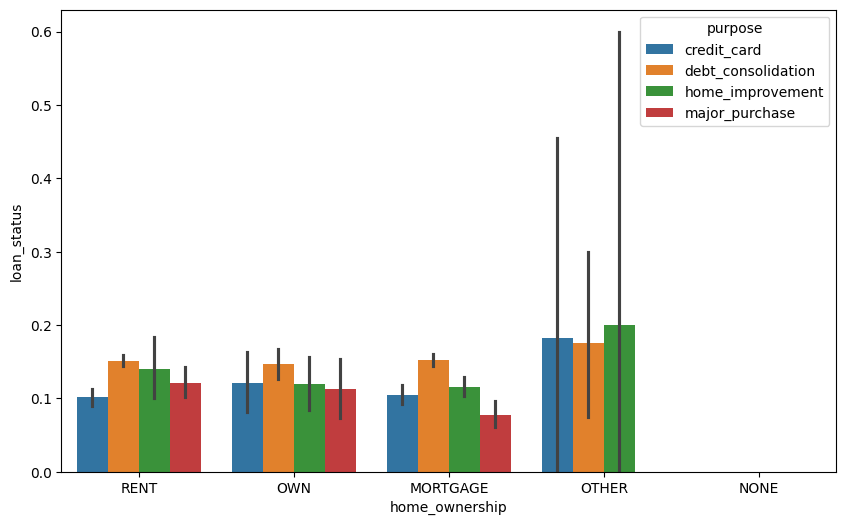

In [102]:
# Call the function to plot the default rate segmented by home ownership status
plot_segmented('home_ownership')

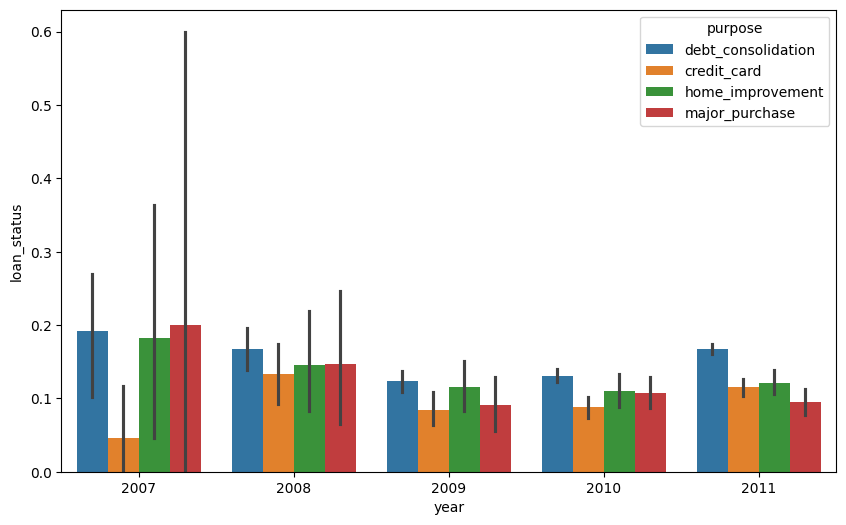

In [103]:
# Call the function to plot the default rate segmented by year of loan issuance
plot_segmented('year')

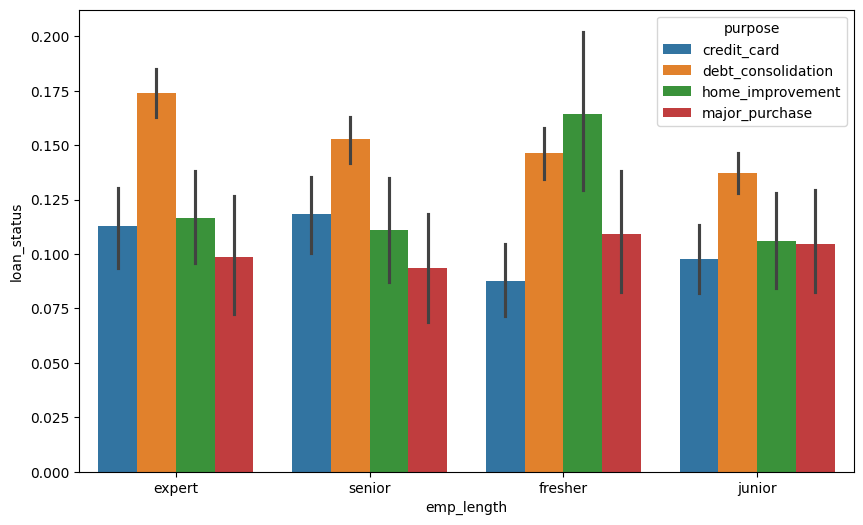

In [104]:
# Call the function to plot the default rate segmented by employment length
plot_segmented('emp_length')

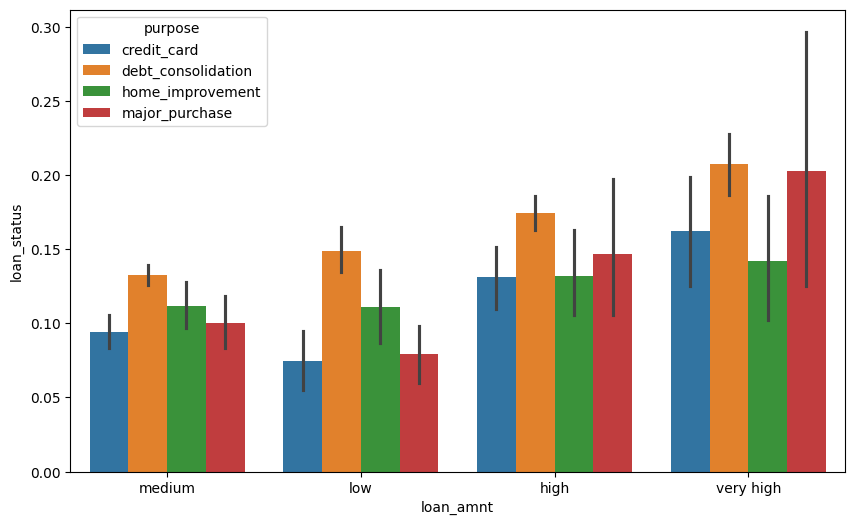

In [105]:
# Call the function to plot the default rate segmented by loan amount
plot_segmented('loan_amnt')

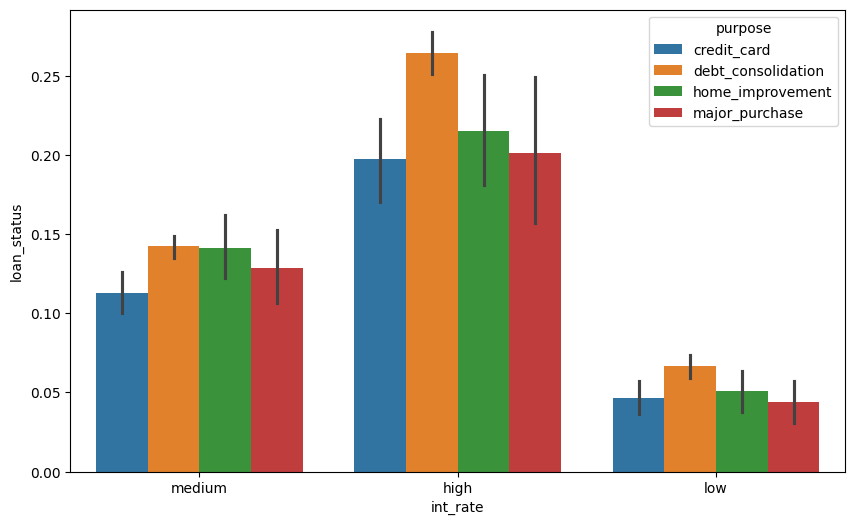

In [106]:
# Plotting the default rates segmented by purpose across different interest rate categories
plot_segmented('int_rate')

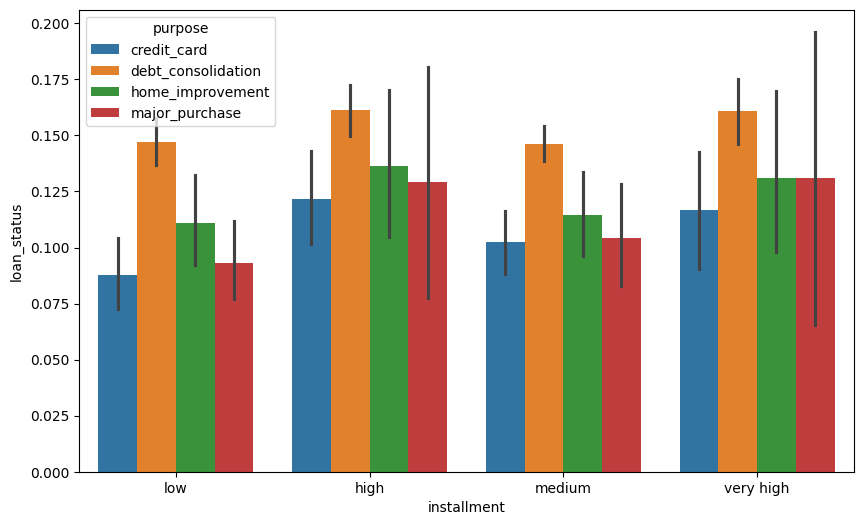

In [107]:
# Plotting default rates across different installment amount categories, segmented by loan purpose
plot_segmented('installment')

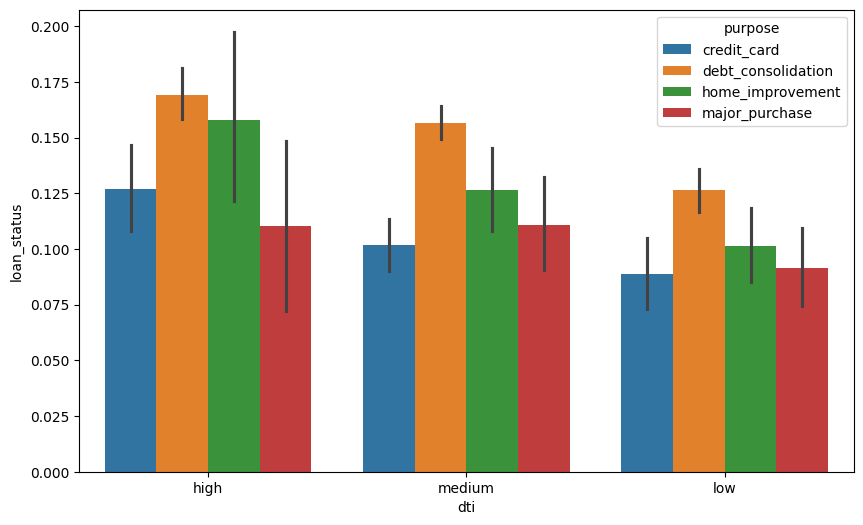

In [108]:
# Plotting default rates across different debt-to-income ratio categories, segmented by loan purpose
plot_segmented('dti')

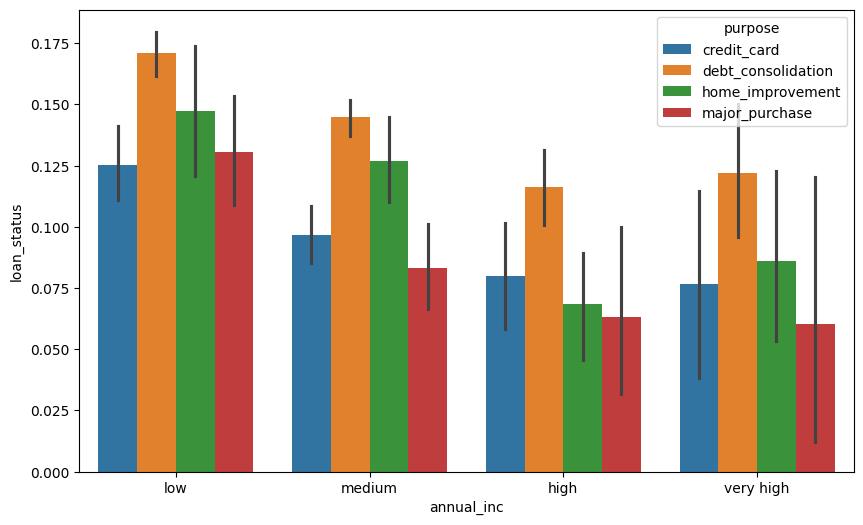

In [109]:
# Plotting default rates across different annual income categories, segmented by loan purpose
plot_segmented('annual_inc')

* A good way to quantify the effect of a categorical variable on default rate is to see 'how much does the default rate vary across the categories'.

* Let's see an example using annual_inc as the categorical variable.

In [110]:
# Calculating the average default rate for each annual income category,
# and sorting them in descending order to observe which income groups have the highest default rates
df.groupby('annual_inc').loan_status.mean().sort_values(ascending=False)

,loan_status
annual_inc,
low,0.157966
medium,0.130075
very high,0.101570
high,0.097749


In [111]:
# This function evaluates how much a categorical variable influences loan default rates.
# It calculates the average default rate for each category of the input variable.
# Then it returns both:
#   1. The default rates per category (rounded to 2 decimal places).
#   2. The difference between the highest and lowest default rate across categories,
#      which serves as a simple metric for the variable's predictive strength.
def diff_rate(cat_var):
    default_rates = df.groupby(cat_var).loan_status.mean().sort_values(ascending=False)
    return (round(default_rates, 2), round(default_rates.iloc[0] - default_rates.iloc[-1], 2))

# Example usage:
default_rates, diff = diff_rate('annual_inc')
# Displays average default rate for each income category
print(default_rates)
# Displays the difference between highest and lowest default rates
print(diff)

annual_inc
low          0.16
medium       0.13
very high    0.10
high         0.10
Name: loan_status, dtype: float64
0.06


* Thus, there is a 6% increase in default rate as you go from high to low annual income.  can compute this difference for all the variables and roughly identify the ones that affect default rate the most.

In [112]:
# Filtering all object-type (categorical) variables from the DataFrame.
# This is useful for analyzing how categorical features affect loan default rates.
df_categorical = df.loc[:, df.dtypes == object].copy()

# Adding the target variable 'loan_status' to this new DataFrame for further analysis.
df_categorical['loan_status'] = df['loan_status']

# Printing all column names in the original DataFrame (df) to review available features.
print([i for i in df.columns])

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'dti', 'initial_list_status', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens', 'month', 'year']


In [113]:
# For each categorical variable in the DataFrame (excluding 'loan_status'), this dictionary comprehension calculates the difference in default rates
# between the highest and lowest category (using the diff_rate function).
# The difference is multiplied by 100 to convert it into a percentage.
# The result is stored in a dictionary `d`, where:
#   - Key = categorical column name
#   - Value = percentage difference in default rates across its categories
d = {key: diff_rate(key)[1]*100 for key in df_categorical.columns if key != 'loan_status'}

# Displaying the resulting dictionary to see how influential each categorical variable is in terms of its effect on loan default rates.
print(d)

{'loan_amnt': np.float64(7.000000000000001), 'funded_amnt': np.float64(7.000000000000001), 'funded_amnt_inv': np.float64(6.0), 'term': np.float64(15.0), 'int_rate': np.float64(19.0), 'installment': np.float64(3.0), 'grade': np.float64(27.0), 'sub_grade': np.float64(46.0), 'emp_title': np.float64(100.0), 'emp_length': np.float64(3.0), 'home_ownership': np.float64(16.0), 'annual_inc': np.float64(6.0), 'verification_status': np.float64(4.0), 'pymnt_plan': np.float64(0.0), 'purpose': np.float64(5.0), 'dti': np.float64(5.0), 'initial_list_status': np.float64(0.0)}


All Loan Statuses:
[0 1]


/tmp/ipykernel_1071/3521047202.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['loan_outcome'] = df['loan_status'].apply(classify_loan_status)


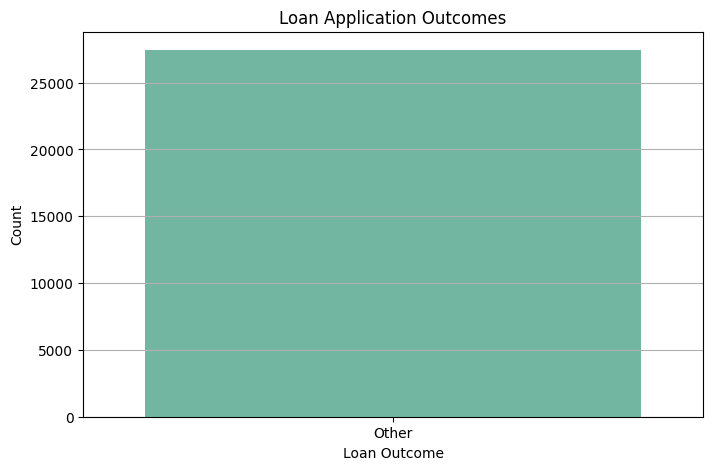


Detailed Loan Status Counts:
loan_status
0    23709
1     3730
Name: count, dtype: int64


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your dataframe and 'loan_status' is the relevant column
# Step 1: View all unique loan statuses
print("All Loan Statuses:")
print(df['loan_status'].unique())

# Step 2: Group statuses into 'Accepted' and 'Rejected' (edit if you have different values)
accepted_statuses = ['Fully Paid', 'Current']
rejected_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period']

# Step 3: Create a new column to label accepted/rejected
def classify_loan_status(status):
    if status in accepted_statuses:
        return 'Accepted'
    elif status in rejected_statuses:
        return 'Rejected'
    else:
        return 'Other'  # e.g., 'Issued', 'Does not meet the credit policy', etc.

df['loan_outcome'] = df['loan_status'].apply(classify_loan_status)

# Step 4: Countplot of all loan outcomes
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_outcome', hue='loan_outcome', data=df, palette='Set2', legend=False)
plt.title('Loan Application Outcomes')
plt.xlabel('Loan Outcome')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

# Step 5: Optional — show count of each detailed loan status
print("\nDetailed Loan Status Counts:")
print(df['loan_status'].value_counts())

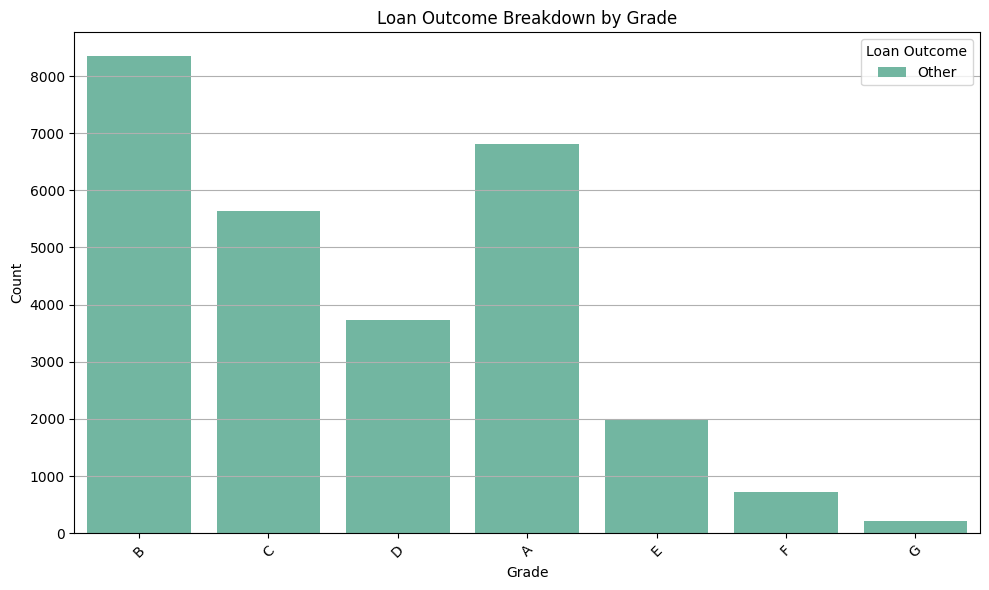

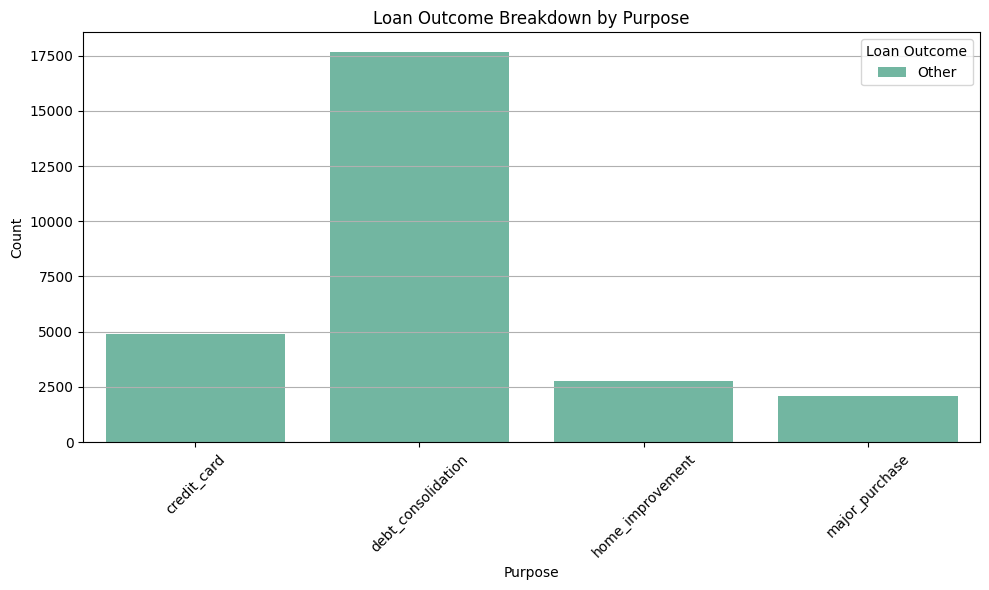

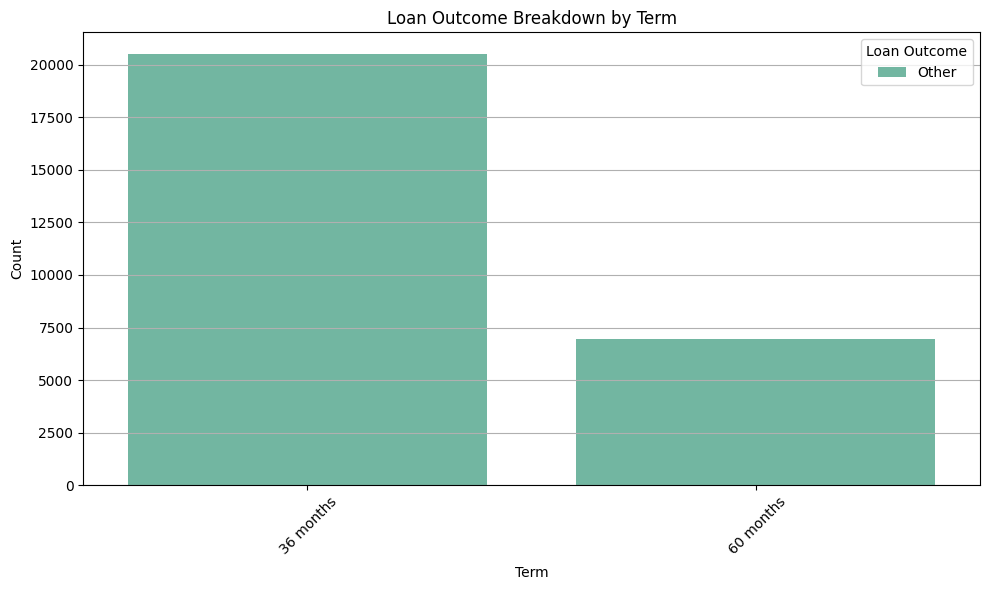

In [115]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to plot loan outcome distribution for any categorical feature
def plot_loan_outcome_breakdown(feature):
    """
    Plots a countplot showing how loan outcomes (Accepted, Rejected, Other)
    vary across different categories of the specified feature.

    Parameters:
    - feature (str): The column name in the DataFrame 'df' (e.g., 'grade', 'purpose', 'term').
    """

    # Set the figure size for better readability
    plt.figure(figsize=(10, 6))

    # Create a countplot grouped by loan outcome for the given feature
    sns.countplot(data=df, x=feature, hue='loan_outcome', palette='Set2')

    # Add chart title and axis labels
    plt.title(f'Loan Outcome Breakdown by {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')

    # Add gridlines along the y-axis for better visual interpretation
    plt.grid(axis='y')

    # Display legend for 'loan_outcome'
    plt.legend(title='Loan Outcome')

    # Rotate x-axis labels if needed (for better visibility)
    plt.xticks(rotation=45)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Display the plot
    plt.show()

# Plot breakdown of loan outcomes by grade
plot_loan_outcome_breakdown('grade')

# Plot breakdown of loan outcomes by loan purpose
plot_loan_outcome_breakdown('purpose')

# Plot breakdown of loan outcomes by loan term
plot_loan_outcome_breakdown('term')

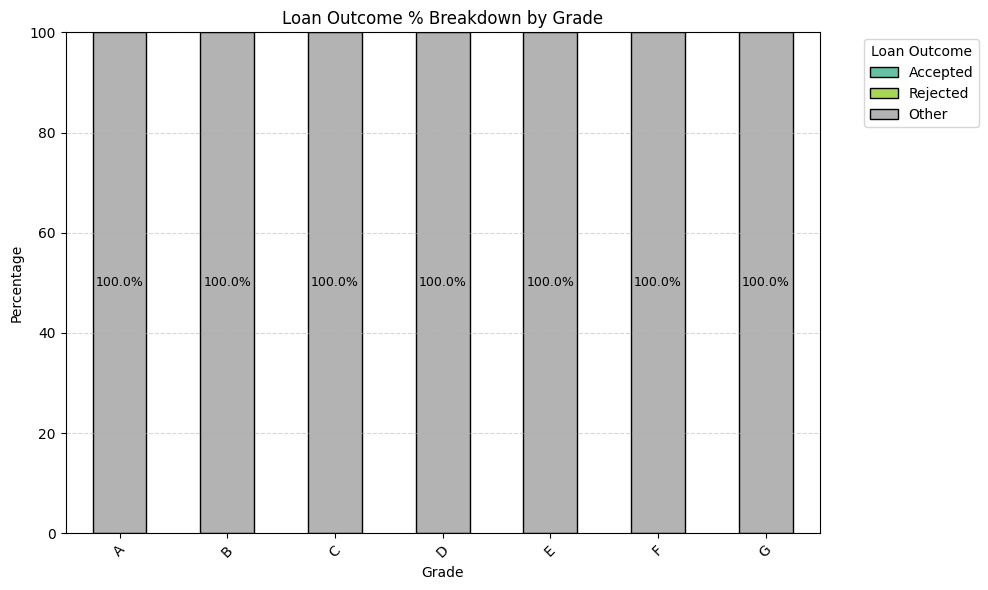

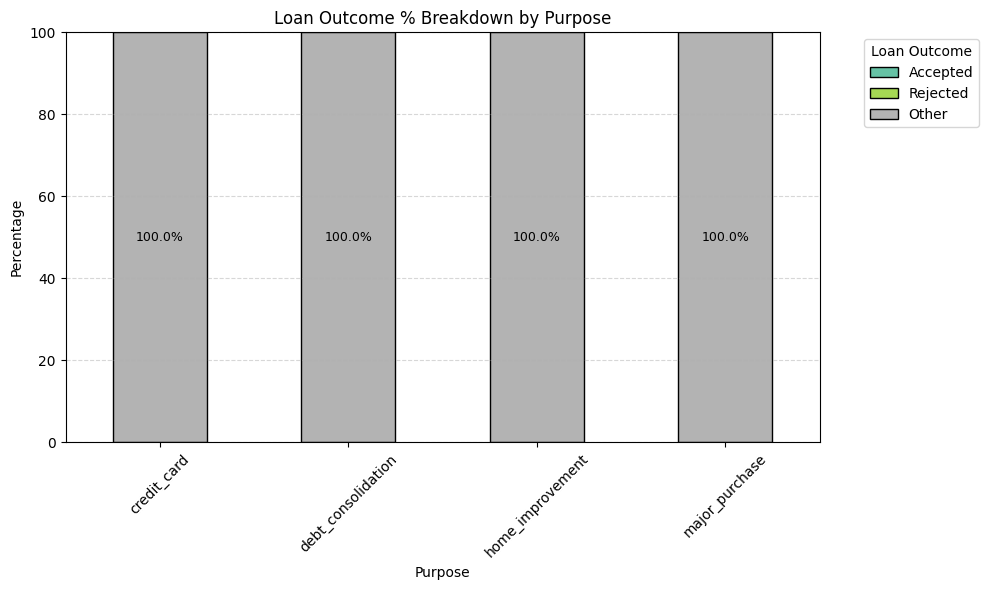

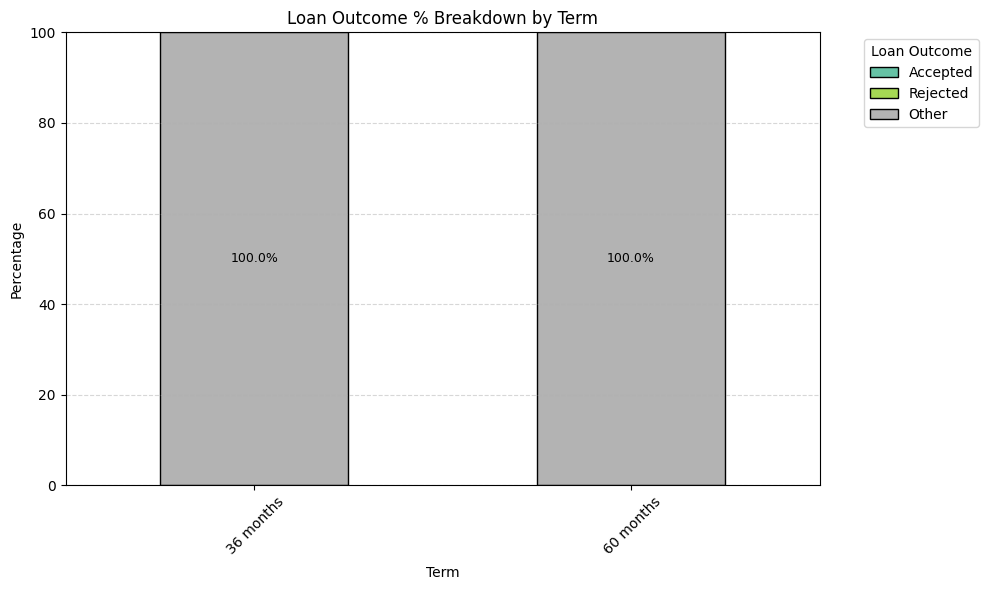

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_percentage_stacked_bar(feature):
    """
    Plots a percentage stacked bar chart showing the breakdown of loan outcomes
    (Accepted, Rejected, Other) across categories of the specified feature.

    Parameters:
    - feature (str): Column name in df (e.g., 'grade', 'purpose', 'term').
    """

    # Step 1: Create a crosstab with normalized values (percentages)
    crosstab = pd.crosstab(df[feature], df['loan_outcome'], normalize='index') * 100

    # Step 2: Ensure all expected loan outcomes are present in the columns
    expected_outcomes = ['Accepted', 'Rejected', 'Other']
    for outcome in expected_outcomes:
        if outcome not in crosstab.columns:
            crosstab[outcome] = 0  # Add missing columns with 0%

    # Step 3: Reorder the columns
    crosstab = crosstab[expected_outcomes]

    # Step 4: Plotting
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')

    # Step 5: Annotate percentages on bars
    for i, category in enumerate(crosstab.index):
        cumulative = 0
        for outcome in crosstab.columns:
            percent = crosstab.loc[category, outcome]
            if percent > 5:
                ax.text(i, cumulative + percent / 2, f'{percent:.1f}%', ha='center', va='center', fontsize=9)
            cumulative += percent

    # Step 6: Format plot
    plt.title(f'Loan Outcome % Breakdown by {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Percentage')
    plt.legend(title='Loan Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Plot for each categorical feature
plot_percentage_stacked_bar('grade')
plot_percentage_stacked_bar('purpose')
plot_percentage_stacked_bar('term')